In [11]:
import os
import uuid
from typing import TypedDict

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import Runnable
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.state import CompiledStateGraph
from langgraph.graph import StateGraph, END

from question_generator_agent.prompts import (
    QUESTION_GENERATION_PROMPT,
    QUESTION_QUALITY_EVALUATION_PROMPT,
    QUESTION_CORRECTION_PROMPT
    )

from question_generator_agent.models import (
    MultipleChoiceQuestion,
    QuestionQualityEvaluation
)

from question_generator_agent.state import QuestionCreationState

from dotenv import load_dotenv

load_dotenv()

class QuestionInput(TypedDict):
    subject_name: str
    subject_content: str
    question_topic: str
    question_type: str
    level: str


class MultipleChoiceQuestionGeneratorAgent:
    def __init__(
        self,
        model_for_generation: str = "gpt-5-nano",
        model_for_evaluation: str = "gpt-5-nano",
        question_generation_prompt: str | None = None,
        question_evaluation_prompt: str | None = None,
        question_correction_prompt: str | None = None,
        api_key: str | None = None,
        temperature: float = 0,
        verbose: bool = False,
        subject_content: str | None = None,
        subject_name: str | None = None,
    ) -> None:

        self.question_generation_prompt = question_generation_prompt or QUESTION_GENERATION_PROMPT
        self.question_evaluation_prompt = question_evaluation_prompt or QUESTION_QUALITY_EVALUATION_PROMPT
        self.question_correction_prompt = question_correction_prompt or QUESTION_CORRECTION_PROMPT
        
        self.verbose = verbose
        self.subject_content = subject_content
        self.subject_name = subject_name

        self._question_generation_chain = self._build_structured_chain(
            prompt=self.question_generation_prompt,
            output_class=MultipleChoiceQuestion,
            model=model_for_generation
        )
        
        self._question_evaluation_chain = self._build_structured_chain(
            prompt=self.question_evaluation_prompt,
            output_class=QuestionQualityEvaluation,
            model=model_for_evaluation
        )
        
        self._question_correction_chain = self._build_structured_chain(
            prompt=self.question_correction_prompt,
            output_class=MultipleChoiceQuestion,
            model=model_for_generation
        )

        self._checkpointer = MemorySaver()
        self._thread_id: str = str(uuid.uuid4())
        self._graph = self._build_graph()
        self._attempts = 0
        
    def _build_structured_chain(self, prompt: str, output_class: type, model: str) -> Runnable:
            llm = ChatOpenAI(
                model=model,
                api_key=os.environ.get("OPENAI_API_KEY"),
                temperature=0,
            ).with_structured_output(output_class)
    
            prompt = ChatPromptTemplate.from_template(prompt)
    
            return prompt | llm

    def _build_input(self, question_topic: str, level: str) -> QuestionInput:
        return QuestionInput(
            subject_name=self.subject_name or "",
            subject_content=self.subject_content or "",
            question_topic=question_topic,
            question_type="múltipla escolha",
            level=level,
        )

    def _create_question_node(self, state: QuestionCreationState) -> QuestionCreationState:
        question_input = self._build_input(
            question_topic=state["question_topic"],
            level=state["level"]
        )
        generated_question = self._question_generation_chain.invoke(question_input)
        state["generated_question"] = generated_question
        return state
    
    def _evaluate_question_node(self, state: QuestionCreationState) -> QuestionCreationState:
        evaluation_input = {
            "generated_question": state["generated_question"],
            "subject_content": state["subject_content"],
        }
        evaluation_result = self._question_evaluation_chain.invoke(evaluation_input)
        state["evaluation"] = evaluation_result
        return state
        
    def _correct_question_node(self, state: QuestionCreationState) -> QuestionCreationState:
        correction_input = {
            "generated_question": state["generated_question"],
            "issues": state["evaluation"].issues if state["evaluation"] else [],
            "subject_content": state["subject_content"],
            "subject_name": state["subject_name"],
            "question_topic": state["question_topic"],
            "question_type": state["question_type"],
            "level": state["level"],
        }
        corrected_question = self._question_correction_chain.invoke(correction_input)
        state["corrected_question"] = corrected_question
        return state
        
    def _build_graph(self) -> CompiledStateGraph:
        graph = StateGraph(QuestionCreationState)
        
        graph.add_node("question_generation", self._create_question_node)
        graph.add_node("question_evaluation", self._evaluate_question_node)
        graph.add_node("question_correction", self._correct_question_node)
        
        graph.add_edge("question_generation", "question_evaluation")
        graph.add_conditional_edges(
            "question_evaluation",
            lambda state: "question_correction" if (state.get("evaluation") and state["evaluation"].issues) else END,
        )
        graph.add_edge("question_evaluation", "question_correction")
        graph.add_edge("question_correction", "question_evaluation")
        
        graph.set_entry_point("question_generation")
        
        app = graph.compile()
                
        return app
    
    def get_graph(self) -> CompiledStateGraph:
        return self._graph

    def invoke(self, question_input: dict) -> MultipleChoiceQuestion:
        full_input = self._build_input(**question_input)
        return self._question_generation_chain.invoke(full_input)


In [12]:
from question_generator_agent.subject_content import SLIDES_CONTENT

from dotenv import load_dotenv

load_dotenv()

True

In [13]:
agent = MultipleChoiceQuestionGeneratorAgent(
    subject_content=SLIDES_CONTENT,
    subject_name="Generative AI e Advanced Analytics",
    )

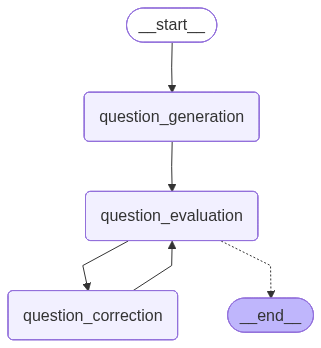

In [14]:
agent.get_graph()